In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("All India Consumer Price Index.csv")
df.head()

,Sector,Year,Month,Cereals and products,Meat and fish,Egg,Milk and products,Oils and fats,Fruits,Vegetables,...,Housing,Fuel and light,Household goods and services,Health,Transport and communication,Recreation and amusement,Education,Personal care and effects,Miscellaneous,General index
0,Rural,2013,January,107.5,106.3,108.1,104.9,106.1,103.9,101.9,...,NaN,105.5,104.8,104.0,103.3,103.4,103.8,104.7,104.0,105.1
1,Urban,2013,January,110.5,109.1,113.0,103.6,103.4,102.3,102.9,...,100.3,105.4,104.8,104.1,103.2,102.9,103.5,104.3,103.7,104.0
2,Rural+Urban,2013,January,108.4,107.3,110.0,104.4,105.1,103.2,102.2,...,100.3,105.5,104.8,104.0,103.2,103.1,103.6,104.5,103.9,104.6
3,Rural,2013,February,109.2,108.7,110.2,105.4,106.7,104.0,102.4,...,NaN,106.2,105.2,104.4,103.9,104.0,104.1,104.6,104.4,105.8
4,Urban,2013,February,112.9,112.9,116.9,104.0,103.5,103.1,104.9,...,100.4,105.7,105.2,104.7,104.4,103.3,103.7,104.3,104.3,104.7


In [3]:
df.columns = df.columns.str.strip()

In [4]:
df['Month'] = df['Month'].astype(str).str.strip().str.title()
df['Month'] = df['Month'].replace({
    'Marchh': 'March',
    'Febuary': 'February',
    'Januray': 'January'
})

In [5]:
df['Month_num'] = pd.to_datetime(
    df['Month'],
    format='%B',
    errors='coerce'
).dt.month

In [6]:
df['Date'] = pd.to_datetime(
    dict(year=df['Year'], month=df['Month_num'], day=1)
)

In [7]:
df = df.dropna(subset=['Date'])
df = df.sort_values(by='Date')
df = df.set_index('Date')

df.head()

,Sector,Year,Month,Cereals and products,Meat and fish,Egg,Milk and products,Oils and fats,Fruits,Vegetables,...,Fuel and light,Household goods and services,Health,Transport and communication,Recreation and amusement,Education,Personal care and effects,Miscellaneous,General index,Month_num
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,Rural,2013,January,107.5,106.3,108.1,104.9,106.1,103.9,101.9,...,105.5,104.8,104.0,103.3,103.4,103.8,104.7,104.0,105.1,1.0
2013-01-01,Urban,2013,January,110.5,109.1,113.0,103.6,103.4,102.3,102.9,...,105.4,104.8,104.1,103.2,102.9,103.5,104.3,103.7,104.0,1.0
2013-01-01,Rural+Urban,2013,January,108.4,107.3,110.0,104.4,105.1,103.2,102.2,...,105.5,104.8,104.0,103.2,103.1,103.6,104.5,103.9,104.6,1.0
2013-02-01,Rural,2013,February,109.2,108.7,110.2,105.4,106.7,104.0,102.4,...,106.2,105.2,104.4,103.9,104.0,104.1,104.6,104.4,105.8,2.0
2013-02-01,Urban,2013,February,112.9,112.9,116.9,104.0,103.5,103.1,104.9,...,105.7,105.2,104.7,104.4,103.3,103.7,104.3,104.3,104.7,2.0


In [8]:
print(df.shape)
print(df.isnull().sum())

(364, 31)
Sector                                   0
Year                                     0
Month                                    0
Cereals and products                     3
Meat and fish                            6
Egg                                      3
Milk and products                        3
Oils and fats                            3
Fruits                                   3
Vegetables                               3
Pulses and products                      3
Sugar and Confectionery                  3
Spices                                   3
Non-alcoholic beverages                  3
Prepared meals, snacks, sweets etc.      6
Food and beverages                       3
Pan, tobacco and intoxicants             6
Clothing                                 6
Footwear                                 6
Clothing and footwear                    6
Housing                                122
Fuel and light                           3
Household goods and services             6
H

In [9]:
df = df.dropna(subset=['General index'])
df = df.interpolate()

C:\Users\hp\AppData\Local\Temp\ipykernel_44496\3808319324.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate()


In [10]:
print(df.isnull().sum())

Sector                                   0
Year                                     0
Month                                    0
Cereals and products                     0
Meat and fish                            0
Egg                                      0
Milk and products                        0
Oils and fats                            0
Fruits                                   0
Vegetables                               0
Pulses and products                      0
Sugar and Confectionery                  0
Spices                                   0
Non-alcoholic beverages                  0
Prepared meals, snacks, sweets etc.      0
Food and beverages                       0
Pan, tobacco and intoxicants             0
Clothing                                 0
Footwear                                 0
Clothing and footwear                    0
Housing                                118
Fuel and light                           0
Household goods and services             0
Health     

# CPI Trend 

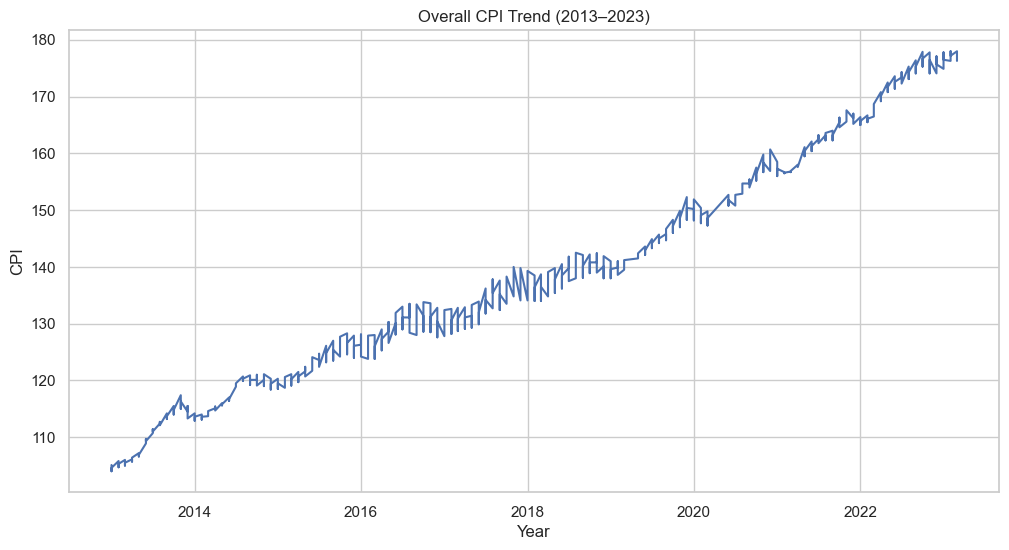

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['General index'])
plt.title("Overall CPI Trend (2013–2023)")
plt.xlabel("Year")
plt.ylabel("CPI")
plt.show()

# Category-wise Analysis

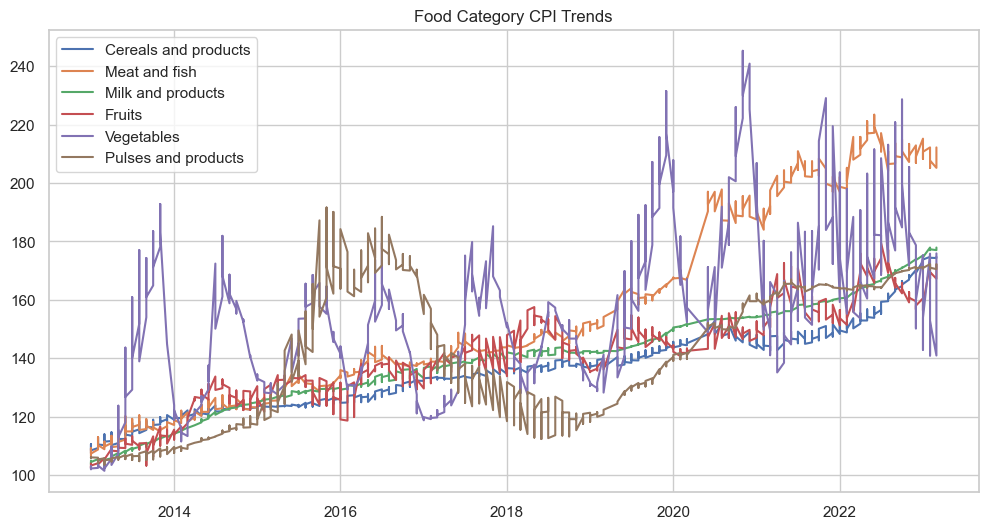

In [12]:
categories = [
    'Cereals and products', 'Meat and fish', 'Milk and products',
    'Oils and Fats', 'Fruits', 'Vegetables', 'Pulses and products'
]

plt.figure(figsize=(12,6))
for col in categories:
    if col in df.columns:
        plt.plot(df.index, df[col], label=col)

plt.legend()
plt.title("Food Category CPI Trends")
plt.show()

# Correlation Heatmap

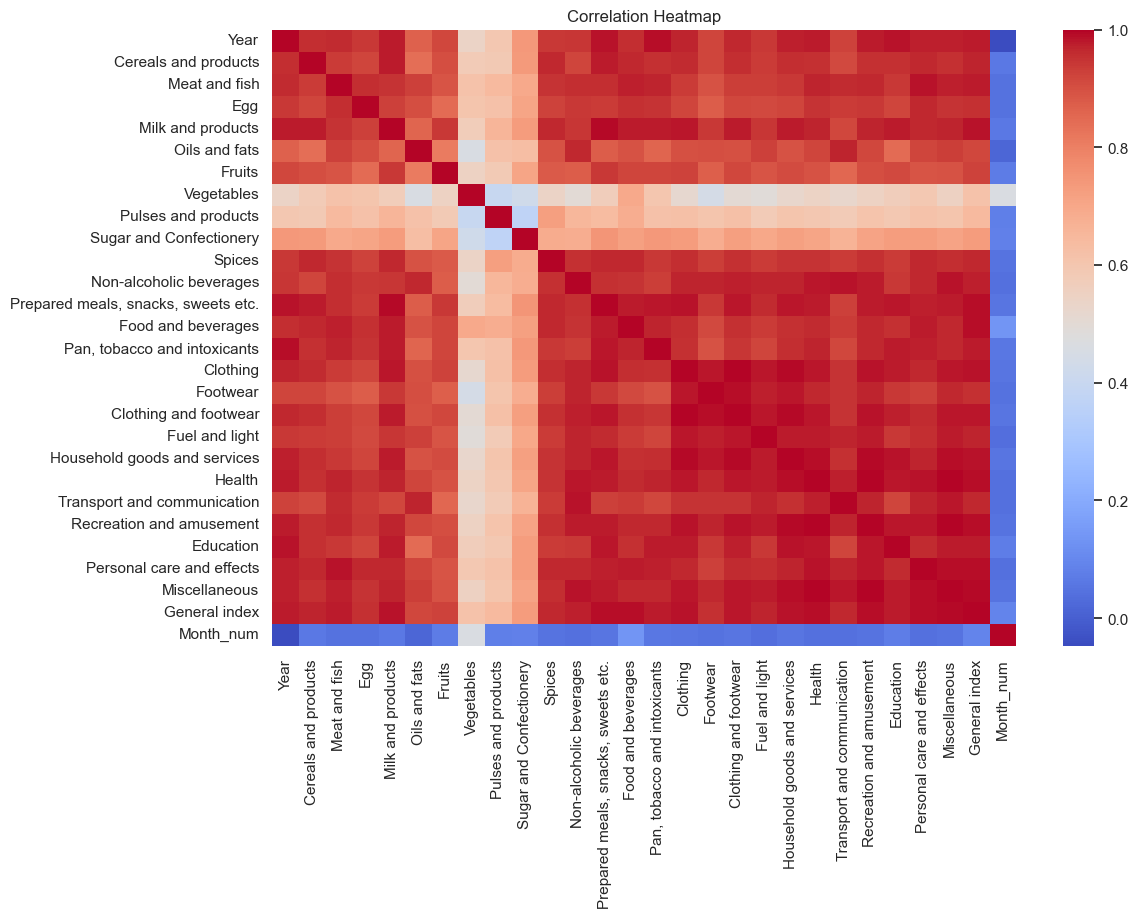

In [13]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Monthly Seasonality

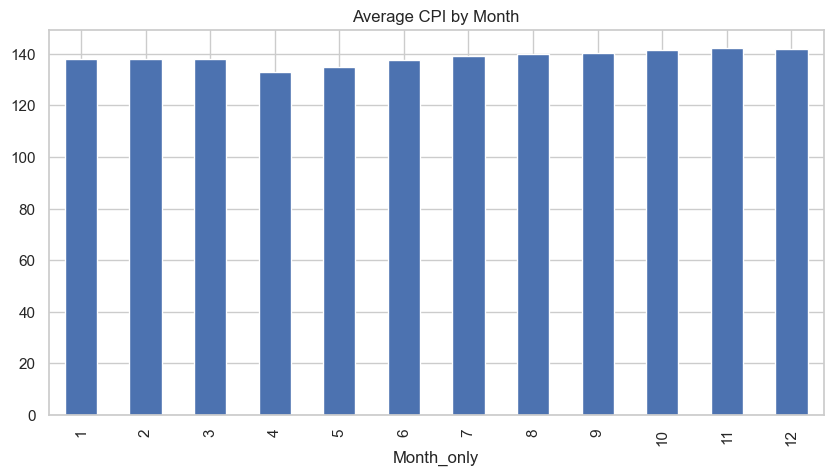

In [14]:
df['Month_only'] = df.index.month

monthly_avg = df.groupby('Month_only')['General index'].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar')
plt.title("Average CPI by Month")
plt.show()

# Moving Average

<Figure size 1200x600 with 0 Axes>

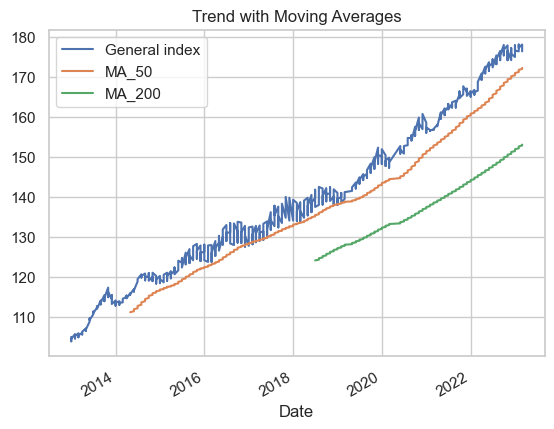

In [15]:
df['MA_50'] = df['General index'].rolling(50).mean()
df['MA_200'] = df['General index'].rolling(200).mean()

plt.figure(figsize=(12,6))
df[['General index', 'MA_50', 'MA_200']].plot()
plt.title("Trend with Moving Averages")
plt.show()

# Stationarity Test (ADF)

In [16]:
result = adfuller(df['General index'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Stationary")
else:
    print("Not Stationary")

ADF Statistic: 0.47569785881010046
p-value: 0.9841154320317804
Not Stationary


# Differencing

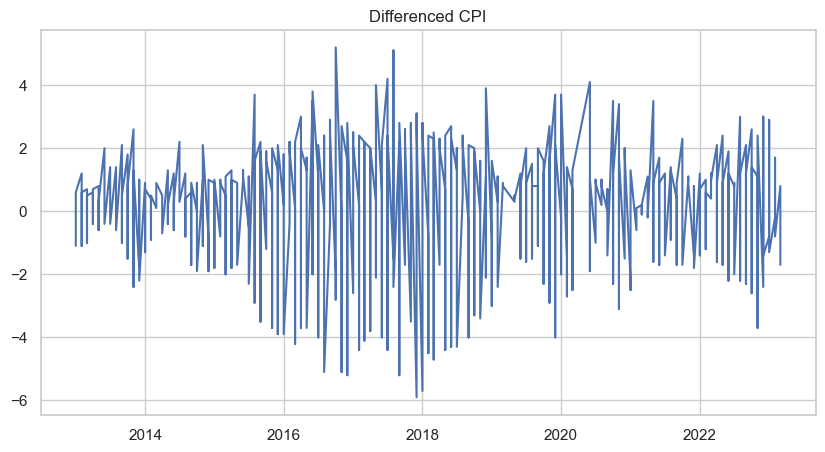

In [17]:
df['CPI_diff'] = df['General index'].diff()

plt.figure(figsize=(10,5))
plt.plot(df['CPI_diff'])
plt.title("Differenced CPI")
plt.show()

# ARIMA Model

In [18]:
model = ARIMA(df['General index'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

C:\Users\hp\anaconda3\envs\tf_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\envs\tf_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\envs\tf_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:          General index   No. Observations:                  358
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -702.655
Date:                Tue, 21 Apr 2026   AIC                           1411.310
Time:                        12:59:58   BIC                           1422.943
Sample:                             0   HQIC                          1415.937
                                - 358                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1613      0.096     -1.672      0.095      -0.350       0.028
ma.L1         -0.5160      0.078     -6.633      0.000      -0.669      -0.364
sigma2         2.9957      0.250     11.989      0.0

# Forecast

C:\Users\hp\anaconda3\envs\tf_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\hp\anaconda3\envs\tf_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


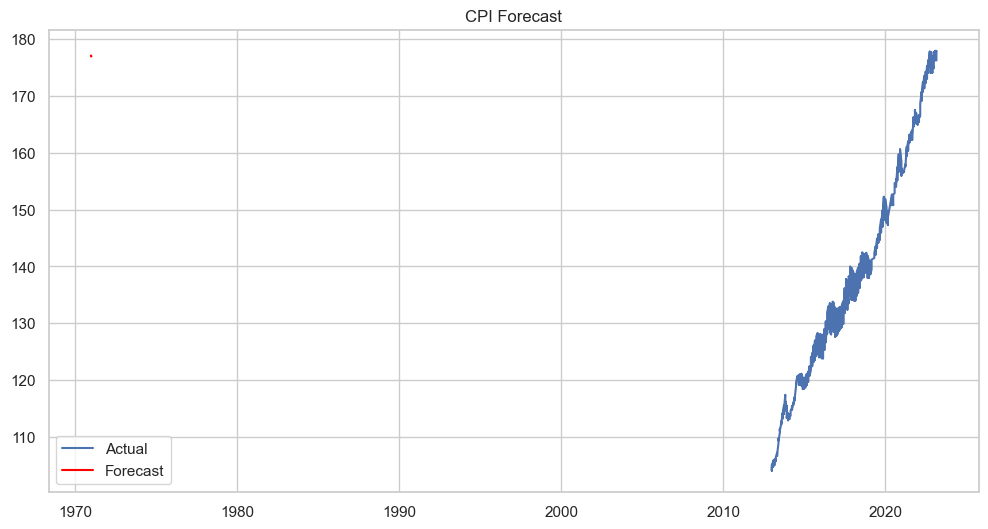

In [19]:
forecast = model_fit.forecast(steps=12)

plt.figure(figsize=(12,6))
plt.plot(df['General index'], label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("CPI Forecast")
plt.show()

# 📊 CPI Analysis

## 🔹 Key Insights
- CPI shows a steady upward trend (inflation)
- Food categories show high volatility
- Seasonal trends exist across months
- Strong correlations between some sectors
- Forecast indicates continued increase